In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import shap
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
import xgboost as xg 
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error, explained_variance_score

pd.options.display.max_rows = 4000
pd.options.display.max_seq_items = 2000

In [2]:
data3060_gpu_conf = pd.read_csv('3060_files/gpu_config.csv')
data3060_cpu_conf = pd.read_csv('3060_files/cpu_config.csv')
data3060_yolo_inf = pd.read_csv('3060_files/yolo_predict.csv')

data3080_gpu_conf = pd.read_csv('3080_files/gpu_config.csv')
data3080_cpu_conf = pd.read_csv('3080_files/cpu_config.csv')
data3080_yolo_inf = pd.read_csv('3080_files/yolo_predict.csv')

dataT4_gpu_conf = pd.read_csv('T4Colab_files/gpu_config.csv')
dataT4_cpu_conf = pd.read_csv('T4Colab_files/cpu_config.csv')
dataT4_yolo_inf = pd.read_csv('T4Colab_files/yolo_predict.csv')

data1650ti_gpu_conf = pd.read_csv('1650ti_files/gpu_config.csv')
data1650ti_cpu_conf = pd.read_csv('1650ti_files/cpu_config.csv')
data1650ti_yolo_inf = pd.read_csv('1650ti_files/yolo_predict.csv')

data2070s_gpu_conf = pd.read_csv('2070s_files/gpu_config.csv')
data2070s_cpu_conf = pd.read_csv('2070s_files/cpu_config.csv')
data2070s_yolo_inf = pd.read_csv('2070s_files/yolo_predict.csv')

In [3]:
data3060_cpu_conf

,Processor,Frequency (MHz),Max Frequency (MHz),Cores,Threads,l1_cache_size (KB),l1_instruction_cache_size (KB),l2_cache_size_per_core (KB),l2_cache_size (KB),l3_cache_size (MB),SMP Supported
0,AMD Ryzen 7 5700X 8-Core Processor,3401.0,3401.0,8,16,Unknown,Unknown,524.288,4194.304,33.554432,True


In [4]:
df_3060 = data3060_yolo_inf.join(data3060_cpu_conf, how='cross')
df_3060 = df_3060.join(data3060_gpu_conf, how='cross')

In [5]:
df_3080 = data3080_yolo_inf.join(data3080_cpu_conf, how='cross')
df_3080 = df_3080.join(data3080_gpu_conf, how='cross')

In [6]:
df_t4 = dataT4_yolo_inf.join(dataT4_cpu_conf, how='cross')
df_t4 = df_t4.join(dataT4_gpu_conf, how='cross')

In [7]:
df_1650ti = data1650ti_yolo_inf.join(data1650ti_cpu_conf, how='cross')
df_1650ti = df_1650ti.join(data1650ti_gpu_conf, how='cross')

In [8]:
df_2070s = data2070s_yolo_inf.join(data2070s_cpu_conf, how='cross')
df_2070s = df_2070s.join(data2070s_gpu_conf, how='cross')

In [12]:
df = pd.concat([df_3060, df_3080, df_t4, df_1650ti, df_2070s])
df['Compute Capability (cuda version)'] = df['Compute Capability (cuda version)'].str.replace(',', '.').str[1:-1].str.replace(' ', '').astype(float)

In [14]:
df.to_csv("data_base.csv", index=False)

In [10]:
df.shape

(7200, 35)

In [16]:
df.isna().any()

cpu_name                             False
gpu_name                             False
gpu_memory                           False
used_gpu                             False
ram_memory                           False
model_name                           False
model_param_dict                     False
num_all_params                       False
model_img_size                       False
image_batch_size                     False
predicting_times                     False
Processor                            False
Frequency (MHz)                      False
Max Frequency (MHz)                  False
Cores                                False
Threads                              False
l1_cache_size (KB)                   False
l1_instruction_cache_size (KB)       False
l2_cache_size_per_core (KB)          False
l2_cache_size (KB)                   False
l3_cache_size (MB)                   False
SMP Supported                        False
GPU Name                             False
Compute Cap

#### 5 на обучение

In [790]:
df_num = df.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)


In [791]:
df_num.dtypes

gpu_memory                           float64
used_gpu                                bool
ram_memory                             int64
num_all_params                         int64
model_img_size                         int64
image_batch_size                       int64
predicting_times                     float64
Frequency (MHz)                      float64
Max Frequency (MHz)                  float64
Cores                                  int64
Threads                                int64
l2_cache_size_per_core (KB)          float64
l2_cache_size (KB)                   float64
l3_cache_size (MB)                   float64
SMP Supported                           bool
Compute Capability (cuda version)    float64
Number of SMs                          int64
Cores per SM                           int64
Total CUDA Cores                       int64
Number of Tensor Cores                 int64
Clock Rate (GHz) boost               float64
FP32 FLOPS (TFLOPS)                  float64
TF32 FLOPS

In [792]:
target = 'predicting_times'
y = df_num[target]
X = df_num.drop(target, axis=1, errors='ignore')

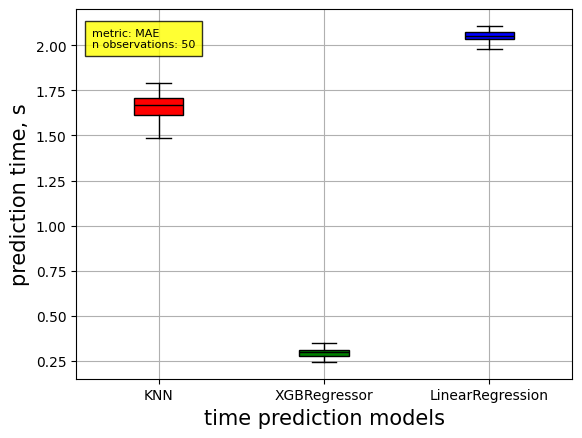

In [793]:
maes_knn = []
maes_xgb = []
maes_linear = []
for _ in range(50):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)
    
    knn = KNeighborsRegressor(n_neighbors=10)
    knn.fit(X_train, y_train)
    pred1 = knn.predict(X_test)
    mae1 = mean_absolute_error(y_test, pred1)
    maes_knn.append(mae1)

    xgb_r = xg.XGBRegressor(n_estimators = 20) 
    xgb_r.fit(X_train, y_train) 
    pred2 = xgb_r.predict(X_test)
    mae2 = mean_absolute_error(y_test, pred2)
    maes_xgb.append(mae2)

    linear = LinearRegression()
    linear.fit(X_train, y_train)
    pred3 = linear.predict(X_test)
    mae3 = mean_absolute_error(y_test, pred3)
    maes_linear.append(mae3)




maes = [maes_knn, maes_xgb, maes_linear]
labels = ['KNN', 'XGBRegressor', 'LinearRegression']
colors = ['red', 'green', 'blue']

fig, ax = plt.subplots()
ax.set_ylabel('prediction time, s', size=15)
ax.set_xlabel('time prediction models', size=15)

bplot = ax.boxplot(maes, patch_artist=True, labels=labels)
for median in bplot['medians']:
    median.set_color('black')
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

xcoords, ycoords = 0.15, 0.8
legen = 'metric: MAE \nn observations: 50'
plt.figtext(xcoords, ycoords, legen, bbox={'facecolor': 'yellow', 'alpha': 0.8, 'pad': 5}, fontsize=8)

plt.grid()
plt.show()

In [794]:
r2_score(y_test, pred2)

0.9638103963321605

In [795]:
mean_absolute_percentage_error(y_test, pred2)

0.5314038716516745

In [796]:
mean_absolute_error(y_test, pred2)

0.29880795685692446

#### SHAP Feature Importance

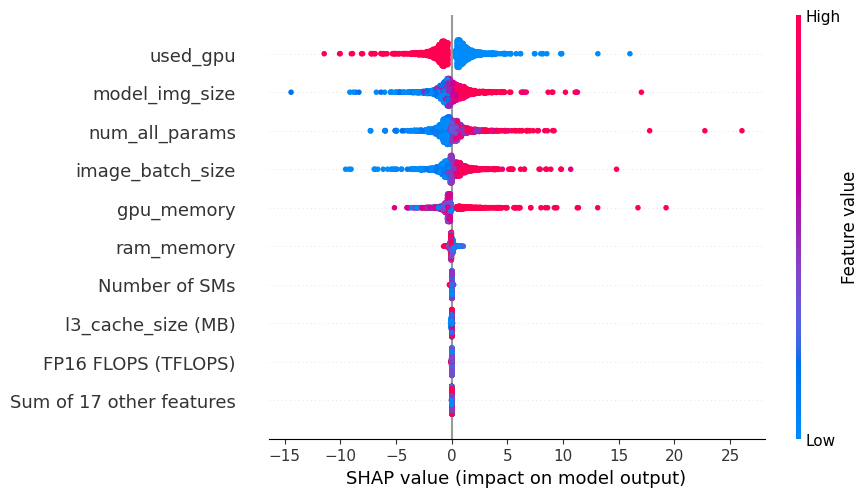

In [797]:
explainer = shap.Explainer(xgb_r)
shap_values = explainer(X_test)
shap.plots.beeswarm(shap_values)

In [798]:
X_test.iloc[100,:]

gpu_memory                               15.0
used_gpu                                 True
ram_memory                                 13
num_all_params                       16576768
model_img_size                            320
image_batch_size                            2
Frequency (MHz)                      2199.998
Max Frequency (MHz)                       0.0
Cores                                       1
Threads                                     2
l2_cache_size_per_core (KB)           262.144
l2_cache_size (KB)                    262.144
l3_cache_size (MB)                   57.67168
SMP Supported                            True
Compute Capability (cuda version)         7.5
Number of SMs                              40
Cores per SM                               64
Total CUDA Cores                         2560
Number of Tensor Cores                    320
Clock Rate (GHz) boost                   1.59
FP32 FLOPS (TFLOPS)                    8.1408
TF32 FLOPS (TFLOPS)               

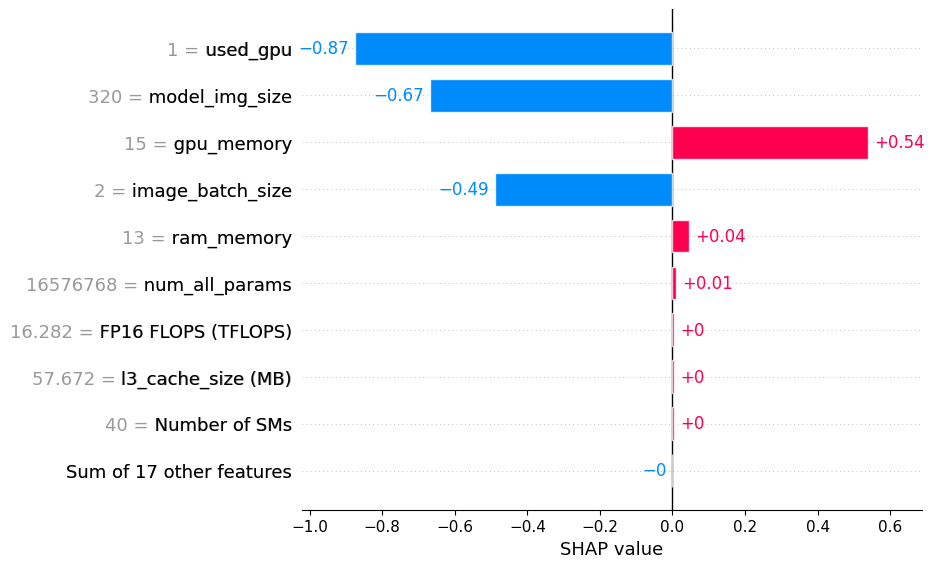

In [799]:
shap.plots.bar(shap_values[100])

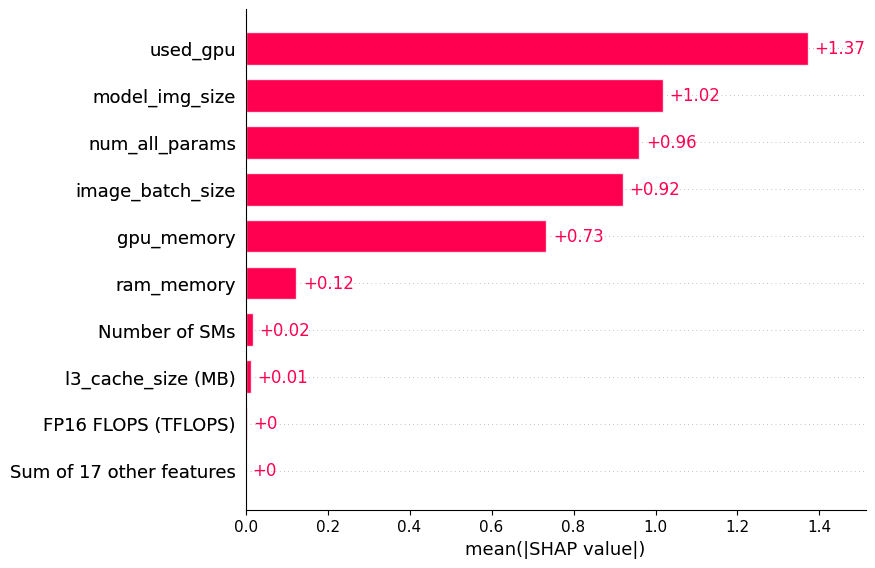

In [800]:
shap.plots.bar(shap_values)

#### 4 на обучение и 1 на предсказание

In [801]:
data3060_gpu_conf = pd.read_csv('3060_files/gpu_config.csv')
data3060_cpu_conf = pd.read_csv('3060_files/cpu_config.csv')
data3060_yolo_inf = pd.read_csv('3060_files/yolo_predict.csv')

data3080_gpu_conf = pd.read_csv('3080_files/gpu_config.csv')
data3080_cpu_conf = pd.read_csv('3080_files/cpu_config.csv')
data3080_yolo_inf = pd.read_csv('3080_files/yolo_predict.csv')

dataT4_gpu_conf = pd.read_csv('T4Colab_files/gpu_config.csv')
dataT4_cpu_conf = pd.read_csv('T4Colab_files/cpu_config.csv')
dataT4_yolo_inf = pd.read_csv('T4Colab_files/yolo_predict.csv')

data1650ti_gpu_conf = pd.read_csv('1650ti_files/gpu_config.csv')
data1650ti_cpu_conf = pd.read_csv('1650ti_files/cpu_config.csv')
data1650ti_yolo_inf = pd.read_csv('1650ti_files/yolo_predict.csv')

data2070s_gpu_conf = pd.read_csv('2070s_files/gpu_config.csv')
data2070s_cpu_conf = pd.read_csv('2070s_files/cpu_config.csv')
data2070s_yolo_inf = pd.read_csv('2070s_files/yolo_predict.csv')

In [802]:
df_3060 = data3060_yolo_inf.join(data3060_cpu_conf, how='cross')
df_3060 = df_3060.join(data3060_gpu_conf, how='cross')

In [803]:
df_3080 = data3080_yolo_inf.join(data3080_cpu_conf, how='cross')
df_3080 = df_3080.join(data3080_gpu_conf, how='cross')

In [804]:
df_t4 = dataT4_yolo_inf.join(dataT4_cpu_conf, how='cross')
df_t4 = df_t4.join(dataT4_gpu_conf, how='cross')

In [ ]:
df_t4

In [805]:
df_1650ti = data1650ti_yolo_inf.join(data1650ti_cpu_conf, how='cross')
df_1650ti = df_1650ti.join(data1650ti_gpu_conf, how='cross')

In [806]:
df_2070s = data2070s_yolo_inf.join(data2070s_cpu_conf, how='cross') # test
df_2070s = df_2070s.join(data2070s_gpu_conf, how='cross')

In [807]:
df_train = pd.concat([df_3060, df_3080, df_t4, df_1650ti])
df_train['Compute Capability (cuda version)'] = df_train['Compute Capability (cuda version)'].str.replace(',', '.').str[1:-1].str.replace(' ', '').astype(float)
df_train_gpu = df_train[df_train['used_gpu'] == True]
df_train_cpu = df_train[df_train['used_gpu'] == False]

df_train_gpu_num = df_train_gpu.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)

df_train_cpu_num = df_train_cpu.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)

df_train_num = df_train.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)

In [808]:
df_2070s['Compute Capability (cuda version)'] = df_2070s['Compute Capability (cuda version)'].str.replace(',', '.').str[1:-1].str.replace(' ', '').astype(float)
df_test_gpu = df_2070s[df_2070s['used_gpu'] == True]
df_test_cpu = df_2070s[df_2070s['used_gpu'] == False]

df_test_gpu_num = df_test_gpu.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)

df_test_cpu_num = df_test_cpu.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)

df_test_num = df_2070s.drop(['cpu_name', 
                'model_name', 
                'model_param_dict', 
                'l1_cache_size (KB)', 
                'l1_instruction_cache_size (KB)', 
                'gpu_name', 
                'GPU Name', 
                'Processor',
                 # 'used_gpu'
                 ], axis=1)

#### для GPU

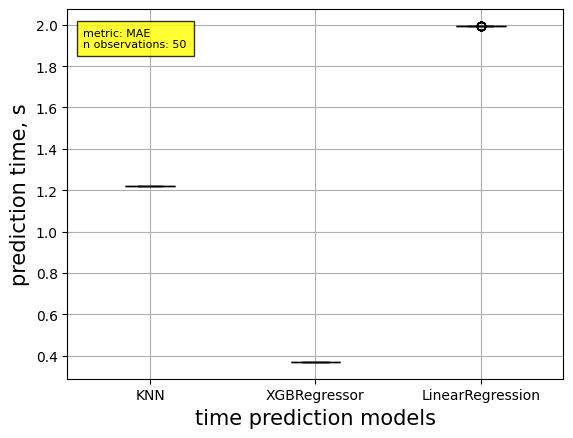

In [809]:
maes_knn = []
maes_xgb = []
maes_linear = []
for _ in range(50):
    # X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True)

    
    target = 'predicting_times'
    df_train_shuffle = df_train_num.sample(frac=1).reset_index(drop=True)
    df_test_shuffle = df_test_num.sample(frac=1).reset_index(drop=True)
    
    y_train = df_train_shuffle[target]
    X_train = df_train_shuffle.drop(target, axis=1, errors='ignore')
    
    y_test = df_test_shuffle[target]
    X_test = df_test_shuffle.drop(target, axis=1, errors='ignore')
    
    knn = KNeighborsRegressor(n_neighbors=10)
    knn.fit(X_train, y_train)
    pred1 = knn.predict(X_test)
    mae1 = mean_absolute_error(y_test, pred1)
    maes_knn.append(mae1)

    xgb_r = xg.XGBRegressor(n_estimators = 20) 
    xgb_r.fit(X_train, y_train) 
    pred2 = xgb_r.predict(X_test)
    mae2 = mean_absolute_error(y_test, pred2)
    maes_xgb.append(mae2)
    

    linear = LinearRegression()
    linear.fit(X_train, y_train)
    pred3 = linear.predict(X_test)
    mae3 = mean_absolute_error(y_test, pred3)
    maes_linear.append(mae3)




maes = [maes_knn, maes_xgb, maes_linear]
labels = ['KNN', 'XGBRegressor', 'LinearRegression']
colors = ['red', 'green', 'blue']

fig, ax = plt.subplots()
ax.set_ylabel('prediction time, s', size=15)
ax.set_xlabel('time prediction models', size=15)

bplot = ax.boxplot(maes, patch_artist=True, labels=labels)
for median in bplot['medians']:
    median.set_color('black')
for patch, color in zip(bplot['boxes'], colors):
    patch.set_facecolor(color)

xcoords, ycoords = 0.15, 0.8
legen = 'metric: MAE \nn observations: 50'
plt.figtext(xcoords, ycoords, legen, bbox={'facecolor': 'yellow', 'alpha': 0.8, 'pad': 5}, fontsize=8)

plt.grid()
plt.show()

In [810]:
r2_score(y_test, pred2)

0.8848498496711353

In [811]:
mean_absolute_percentage_error(y_test, pred2)

0.8699231948454389

In [812]:
mean_absolute_error(y_test, pred2)

0.3692953492438796

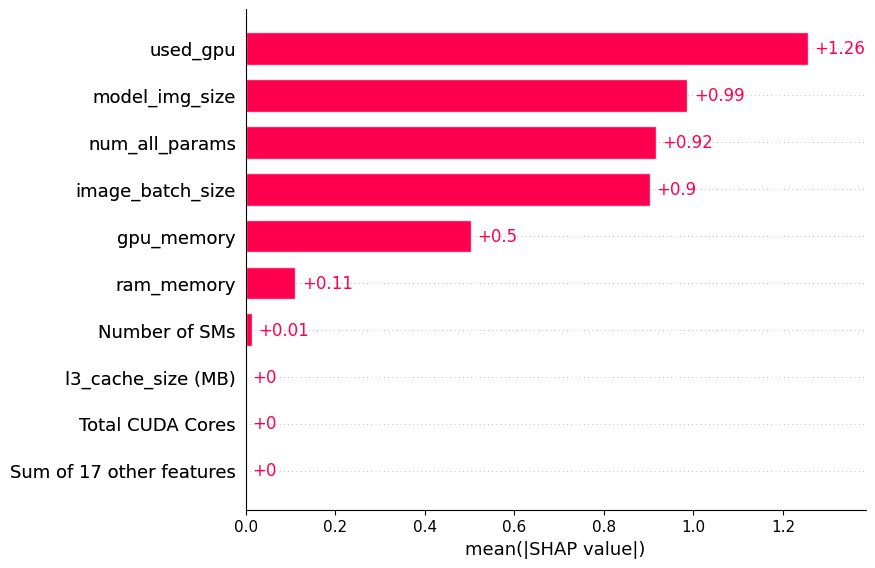

In [813]:
explainer = shap.Explainer(xgb_r)
shap_values = explainer(X_test)
shap.plots.bar(shap_values)

#### Using GPU

In [814]:
gpu_graph_gpu = df.loc[(df['model_img_size'] == 1120) & 
(df['image_batch_size'] == 10) &
(df['model_name'] == 'yolo11l.pt') &
(df['used_gpu'] == True)]

In [815]:
img_graph_gpu = df.loc[(df['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(df['image_batch_size'] == 10) &
(df['model_name'] == 'yolo11l.pt') &
(df['used_gpu'] == True)]

In [816]:
batch_graph_gpu = df.loc[(df['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(df['model_img_size'] == 1120) &
(df['model_name'] == 'yolo11l.pt') &
(df['used_gpu'] == True)]

In [817]:
model_graph_gpu = df.loc[(df['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(df['model_img_size'] == 1120) &
(df['image_batch_size'] == 10) &
(df['used_gpu'] == True)]

#### Using CPU

In [818]:
cpu_graph_cpu = df.loc[(df['model_img_size'] == 1120) & 
(df['image_batch_size'] == 10) &
(df['model_name'] == 'yolo11l.pt') &
(df['used_gpu'] == False)]

In [819]:
img_graph_cpu = df.loc[(df['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(df['image_batch_size'] == 10) &
(df['model_name'] == 'yolo11l.pt') &
(df['used_gpu'] == False)]

In [820]:
batch_graph_cpu = df.loc[(df['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(df['model_img_size'] == 1120) &
(df['model_name'] == 'yolo11l.pt') &
(df['used_gpu'] == False)]

In [821]:
model_graph_cpu = df.loc[(df['gpu_name'] == 'NVIDIA GeForce RTX 3060') & 
(df['model_img_size'] == 1120) &
(df['image_batch_size'] == 10) &
(df['used_gpu'] == False)]

In [822]:
def show_graph(df, x):
    if x in ['cpu_name', 'gpu_name']:
        x_vals = df[[x, 'ram_memory']].to_dict('list')
        x_vals = [f"{gpu} \n ram_memory: {ram}" for gpu, ram in zip(x_vals[x], x_vals['ram_memory'])]
    else:
        x_vals = df[x].to_list()
        x_vals = list(map(lambda x: str(x), x_vals))
    
    
    y_vals = df['predicting_times'].to_list()

    df1 = df.loc[:, ['gpu_name', 'cpu_name', 'ram_memory', 'used_gpu', 'model_name', 'model_img_size', 'image_batch_size']]
    if x == 'cpu_name':
        df1.drop(['gpu_name', 'ram_memory'], axis=1, inplace=True)
    elif x == 'gpu_name':
        df1.drop(['cpu_name', 'ram_memory'], axis=1, inplace=True)
    df1.drop(x, axis=1, inplace=True)
    legen = '\n'.join(str(*df1.head(1).to_dict('records')).strip('{}').split(','))
    
    plt.figure(figsize=(6, 6))
    plt.bar(x_vals, y_vals, color=['blue', 'green', 'red'], width=0.5)
    plt.xlabel(x, size=15)
    plt.ylabel('predicting_time, s', size=15)
    plt.title(f'Сравнение {x}')
    if x == 'model_name':
        plt.xticks(rotation=90)
    elif x in ['cpu_name', 'gpu_name']:
        plt.xticks(rotation=45)
    else:
        plt.xticks(rotation=0)
    ax = plt.gca()
    ax.set_ylim([0, max(y_vals) * 1.3])
    xcoords, ycoords = 0.15, 0.75
    plt.figtext(xcoords, ycoords, legen, bbox={'facecolor': 'yellow', 'alpha': 0.8, 'pad': 5}, fontsize=8)
    plt.grid()
    plt.show()

#### Using GPU

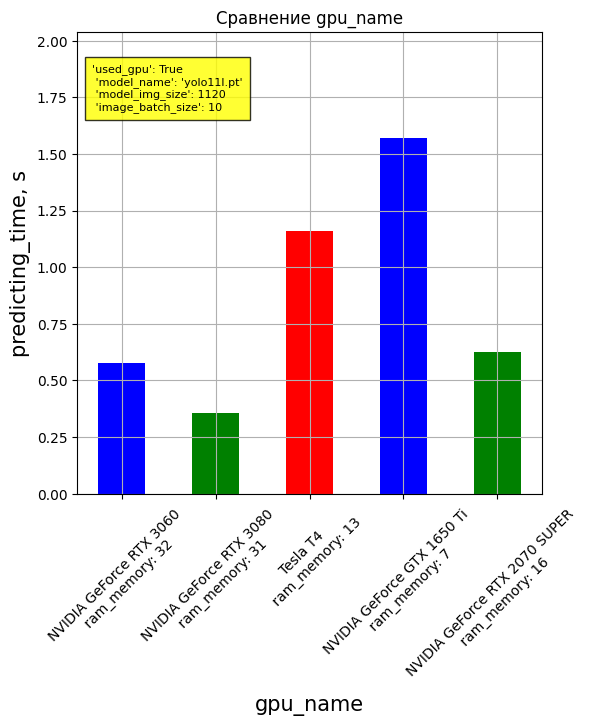

In [823]:
show_graph(gpu_graph_gpu, 'gpu_name')

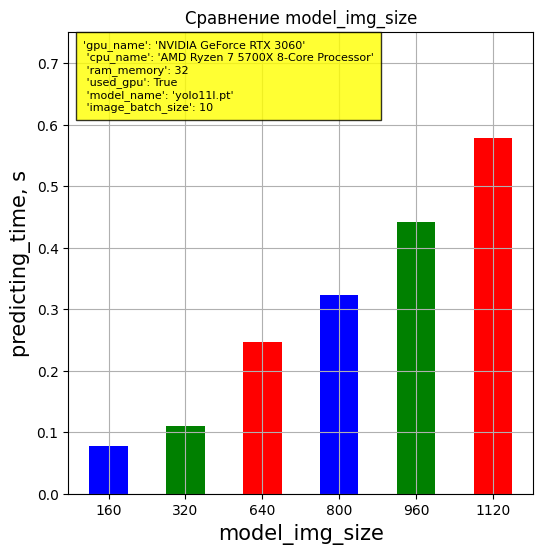

In [824]:
show_graph(img_graph_gpu, 'model_img_size')

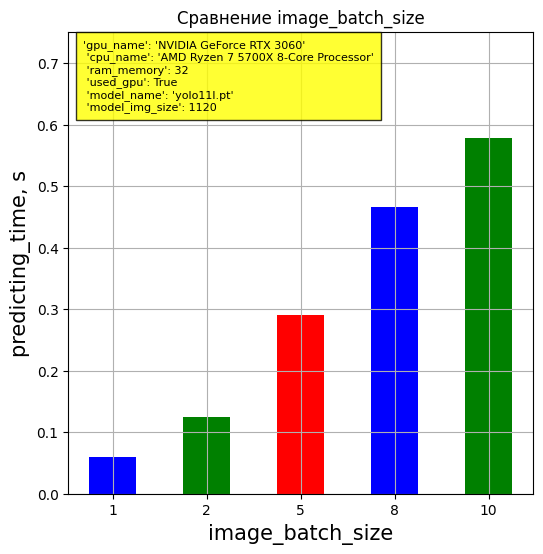

In [825]:
show_graph(batch_graph_gpu, 'image_batch_size')

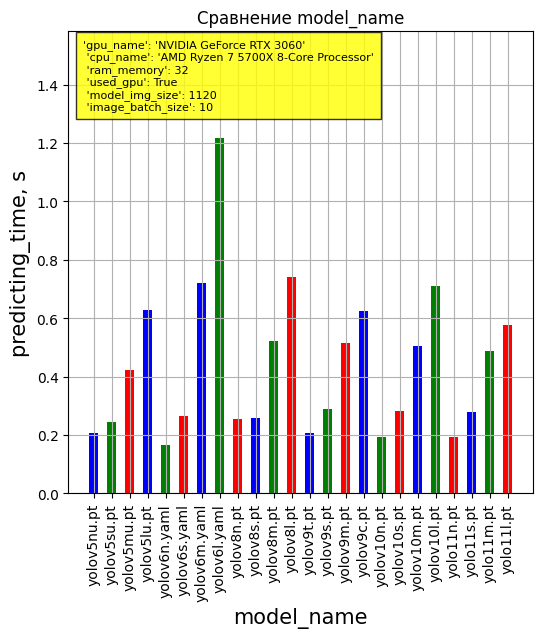

In [826]:
show_graph(model_graph_gpu, 'model_name')

#### Using CPU

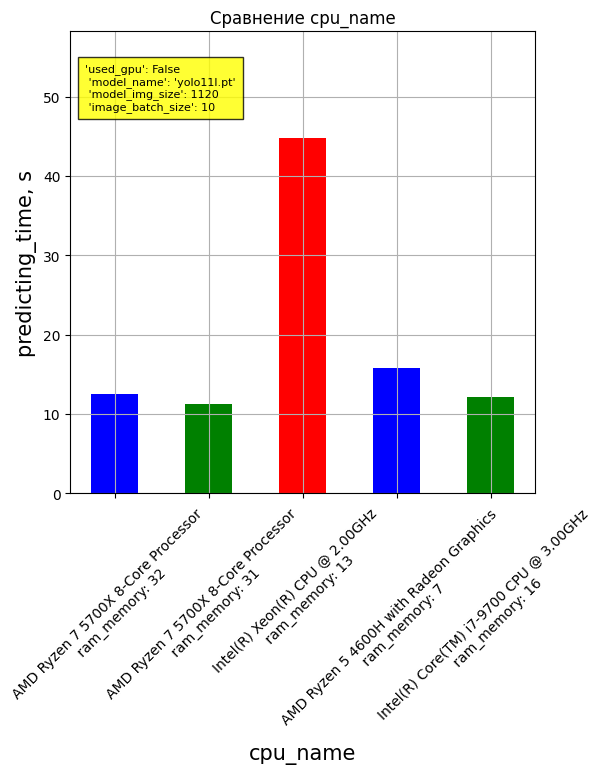

In [827]:
show_graph(cpu_graph_cpu, 'cpu_name')

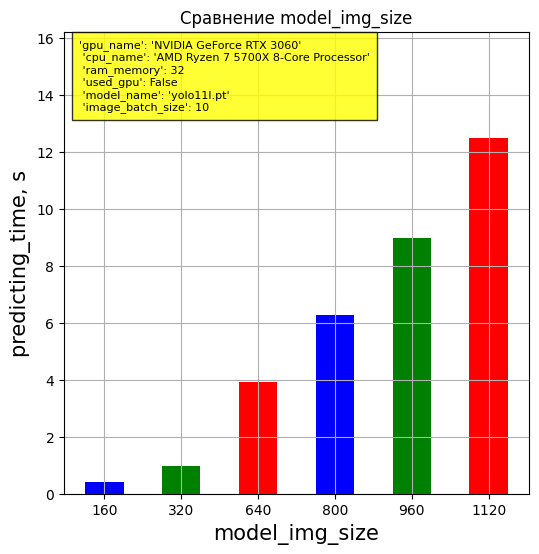

In [828]:
show_graph(img_graph_cpu, 'model_img_size')

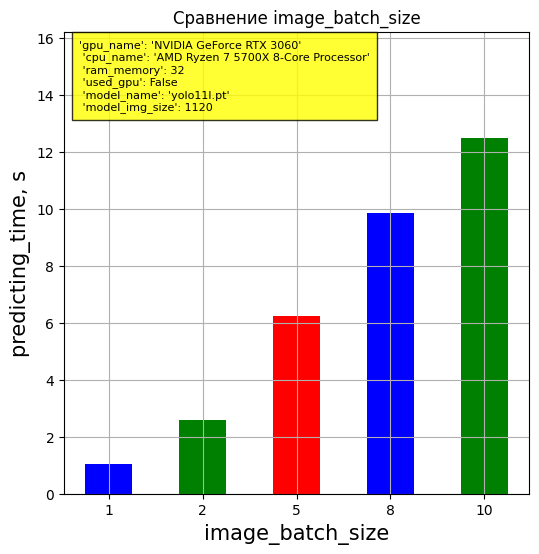

In [829]:
show_graph(batch_graph_cpu, 'image_batch_size')

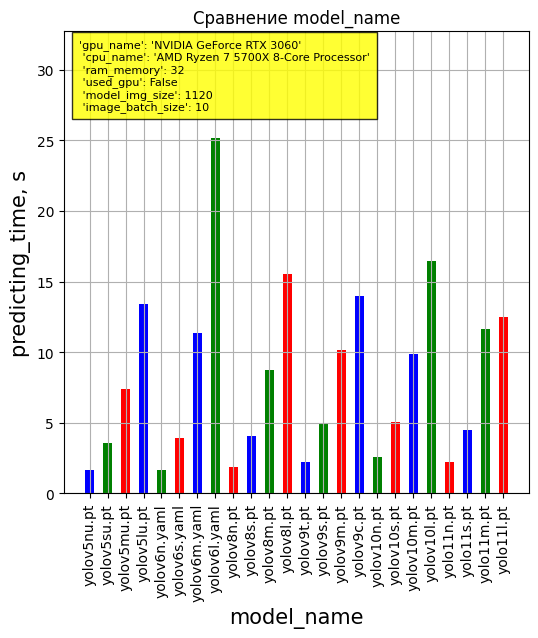

In [830]:
show_graph(model_graph_cpu, 'model_name')